#                   🧠 Week 6 — Day 1
## Sprint 1 Planning & Neural Network Architecture
### Phase 3 — Deep Learning & Applied Project | BinX Tech AI & ML Internship
![status](https://img.shields.io/badge/status-complete-brightgreen) ![phase](https://img.shields.io/badge/phase-3%20%7C%20Deep%20Learning-blueviolet) ![dataset](https://img.shields.io/badge/dataset-Heart%20Failure-red) ![python](https://img.shields.io/badge/python-3.10%2B-blue) ![libraries](https://img.shields.io/badge/libraries-TensorFlow%20%7C%20Keras%20%7C%20Scikit--learn-orange) ![baseline](https://img.shields.io/badge/baseline-Logistic%20Regression-darkgreen)
| | |
|---|---|
| **Intern** | Zayan Shawareb |
| **Program** | BinX Tech — AI & Machine Learning Internship |
| **Phase** | Phase 3 — Deep Learning & Applied Project (Sprint 1 of 4) |
| **Capstone** | Cardiac Patient Monitoring System |
| **Focus** | Sprint 1 Planning • Neural Network Architecture • Baseline Model |
| **Hours** | 8 |

---

> *"The neuron is not new math — it is the Week 2 dot product plus a bias plus an activation. A neural network is that same operation, stacked and repeated."*
> — BinX Tech, Week 6 Curriculum

---

### 📑 Table of Contents
1. [Sprint 1 Planning](#1-sprint-1-planning--the-baseline-first)
2. [Why Deep Learning?](#2-why-deep-learning)
3. [The Neuron](#3-the-neuron)
4. [Layers & Architecture](#4-layers--architecture)
5. [Weights & Biases](#5-weights--biases-are-whats-learned)
6. [🔬 Hands-On Lab: Sprint 1 Kickoff & Baseline](#6-hands-on-lab-sprint-1-kickoff--baseline)
7. [Git Workflow](#7-commit--open-a-draft-pull-request)
8. [Key Takeaways & Next Steps](#8-key-takeaways--next-steps)


## 🎯 Learning Objectives

By the end of today I will be able to:

- [x] Complete Sprint 1 planning and establish a **baseline model** for the Phase 3 capstone project.
- [x] Explain a single **neuron** as a weighted sum, bias, and activation.
- [x] Describe the role of **input, hidden, and output layers** and what "deep" means.
- [x] Explain why **weights and biases** are the parameters a network learns.
- [x] Kick off Sprint 1 of the Cardiac Patient Monitoring System capstone with a documented baseline.


## 1. Sprint 1 Planning & the Baseline First

Phase 3 runs across **4 one-week sprints**. Today is **Sprint Planning (Day 1)** of **Sprint 1**, following the program's standard sprint cycle:

| Event | When | Description |
|---|---|---|
| Sprint Planning | Day 1 | Confirm the Sprint 1 goal (set in Week 5), select backlog tasks, commit to the goal |
| Daily Stand-up | Daily | 3-minute update: done / next / blockers |
| Mentor Code & Notebook Review | Day 3 | Mentor reviews the notebook via GitHub pull request |
| Sprint Review | Day 5 | Demo completed work; unfinished tasks roll to Sprint 2 |
| Sprint Retrospective | Day 5 | What went well, what to improve, one action for Sprint 2 |

**Sprint 1's real objective is to establish a baseline** — a simple model (logistic regression, from Weeks 3–4) whose score *every later model, including this week's neural network, must beat.* Without a baseline, a neural network's score is meaningless.

### 📋 Sprint 1 Plan — Cardiac Patient Monitoring System

| Field | Entry |
|---|---|
| **Sprint Goal** | Establish a clean, validated dataset and a baseline classification model (Logistic Regression) for heart-disease prediction, whose metric will be the benchmark for the Sprint-1 neural network. |
| **Backlog — Task 1** | Finalize dataset & re-run a brief EDA sanity check (`heart.csv`, 918 rows, 12 columns) |
| **Backlog — Task 2** | Train a baseline Logistic Regression model and record its metric (Accuracy + ROC-AUC) |
| **Backlog — Task 3** | Commit the baseline notebook to a feature branch and open a draft pull request |
| **Backlog — Task 4** | Document the baseline score in Markdown as the number every later model must beat |
| **Definition of Done** | Notebook runs top-to-bottom with no errors, baseline metric recorded in a Markdown cell, code pushed to `week6/day1` branch, draft PR opened |
| **Known blockers carried from Week 4** | `Cholesterol` has ~172 rows (≈19%) with an invalid value of `0`; `RestingBP` has 1 row with value `0` — both need imputation before training |

> ✅ **Sprint 1 goal confirmed.** Moving to backlog Task 1.


In [1]:
# 📦 Setup — imports & notebook style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
print("✅ Environment ready.")


✅ Environment ready.


## 2. Why Deep Learning?

Classical ML (Weeks 3–4 — logistic regression, decision trees) works well on **structured, tabular data** like our cardiac dataset. Deep learning shines where classical methods struggle: **images, text, audio**, and other high-dimensional, unstructured data with complex patterns.

A neural network **learns its own features** directly from raw data instead of relying on hand-engineered ones — which is exactly why it powers modern computer vision and NLP (Weeks 7–8).

> 💡 For the Cardiac Patient Monitoring System, our data is tabular (age, cholesterol, chest-pain type, etc.), so the baseline logistic regression is a *very* strong, fair benchmark. Sprint 1's neural network has to earn its place by beating it — not just by being "deep."


## 3. The Neuron

A single neuron is exactly the operation from **Week 2**: it takes inputs, multiplies each by a weight, sums them, adds a bias, then passes the result through an **activation function**.

$$
z = (x_1 w_1) + (x_2 w_2) + \dots + (x_n w_n) + b \;=\; \mathbf{w}\cdot\mathbf{x} + b
$$

$$
\text{output} = \text{activation}(z)
$$

A neural network is just **many of these neurons connected in layers**.

Let's implement one neuron by hand with NumPy, using two toy cardiac-style features (standardized age and standardized max heart rate) so the "framework" never feels like magic.


In [2]:
# 🔧 A single neuron, from scratch — the Week 2 dot product + bias + activation

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Toy input: [standardized_age, standardized_max_HR] for one patient
x = np.array([0.8, -1.2])          # inputs
w = np.array([0.5, -0.9])          # weights  (random, untrained)
b = 0.1                             # bias

z = np.dot(w, x) + b                # <- the Week 2 dot product
output = sigmoid(z)

print(f"z (weighted sum + bias) = {z:.4f}")
print(f"output = sigmoid(z)     = {output:.4f}  -> predicted probability of heart disease")


z (weighted sum + bias) = 1.5800
output = sigmoid(z)     = 0.8292  -> predicted probability of heart disease


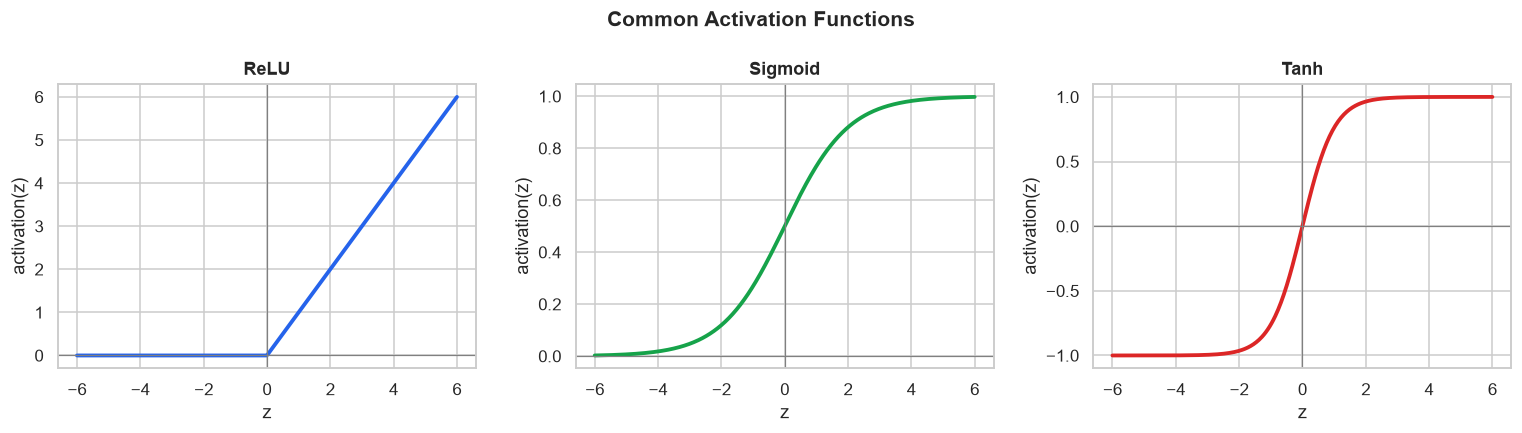

Rule of thumb: ReLU for hidden layers, Sigmoid for binary output (our case!),
Softmax for multi-class output, Tanh when zero-centered hidden output helps.


In [3]:
# 📊 Visualizing common activation functions

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

z_vals = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
funcs = [("ReLU", relu, "#2563eb"), ("Sigmoid", sigmoid, "#16a34a"), ("Tanh", tanh, "#dc2626")]

for ax, (name, fn, color) in zip(axes, funcs):
    ax.plot(z_vals, fn(z_vals), color=color, linewidth=2.5)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("z")
    ax.set_ylabel("activation(z)")

plt.suptitle("Common Activation Functions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Rule of thumb: ReLU for hidden layers, Sigmoid for binary output (our case!),")
print("Softmax for multi-class output, Tanh when zero-centered hidden output helps.")


## 4. Layers & Architecture

Neurons are organized into layers, and data flows through them in order:

| Layer | Role |
|---|---|
| **Input layer** | Receives the raw features — one node per feature (for our dataset: age, sex, chest-pain type, resting BP, cholesterol, etc.) |
| **Hidden layer(s)** | Learn intermediate representations; more/wider layers = more capacity |
| **Output layer** | Produces the final prediction — 1 sigmoid node for our binary heart-disease task |

"**Deep**" learning simply means a network with **multiple hidden layers**. Each layer transforms its input and passes the result forward, and stacking layers lets the network learn increasingly abstract patterns.


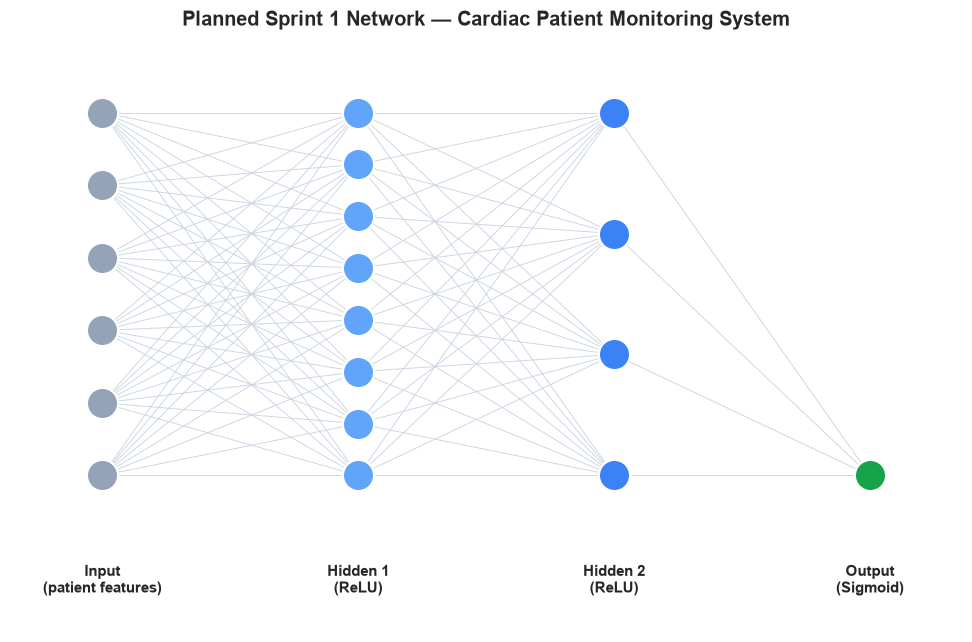

In [4]:
# 🎨 Drawing our planned Sprint-1 network architecture for the cardiac project

fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")

layer_sizes = [6, 8, 4, 1]           # input(shown truncated) -> hidden1 -> hidden2 -> output
layer_names = ["Input\n(patient features)", "Hidden 1\n(ReLU)", "Hidden 2\n(ReLU)", "Output\n(Sigmoid)"]
layer_x = np.linspace(0.08, 0.92, len(layer_sizes))
colors = ["#94a3b8", "#60a5fa", "#3b82f6", "#16a34a"]

positions = []
for n, x in zip(layer_sizes, layer_x):
    ys = np.linspace(0.15, 0.85, n)
    positions.append([(x, y) for y in ys])

# edges
for l in range(len(positions) - 1):
    for (x1, y1) in positions[l]:
        for (x2, y2) in positions[l + 1]:
            ax.plot([x1, x2], [y1, y2], color="#cbd5e1", linewidth=0.6, zorder=1)

# nodes
for l, layer in enumerate(positions):
    for (x, y) in layer:
        ax.scatter(x, y, s=420, color=colors[l], edgecolor="white", linewidth=1.5, zorder=2)

for x, name in zip(layer_x, layer_names):
    ax.text(x, -0.02, name, ha="center", va="top", fontsize=10, fontweight="bold", transform=ax.transData)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.15, 1.0)
ax.set_title("Planned Sprint 1 Network — Cardiac Patient Monitoring System", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Weights & Biases Are What's Learned

The weights and biases are the network's **parameters** — the numbers adjusted during training. A fresh network starts with **random weights** and makes random predictions; training is the process of nudging these weights until the predictions become accurate. Everything on Days 2–3 (activations/forward pass, then backpropagation/gradient descent) is about *how* that nudging works.

> 🧠 **Keep this in mind and the framework code stops being magic:** a neural network is the Week 2 dot product, stacked and repeated.


## 6. 🔬 Hands-On Lab: Sprint 1 Kickoff & Baseline

**Steps:**
1. ✅ Complete Sprint 1 planning (done above).
2. Finalize the project dataset and re-run a brief EDA.
3. Train a simple baseline model (Logistic Regression) and record its metric.
4. Commit the baseline notebook to a feature branch and open a draft pull request.
5. Document the baseline score in Markdown — the number every later model must beat.

### Step 2 — Load the dataset & sanity-check EDA


In [6]:
# 📂 Load the Cardiac Patient Monitoring System dataset
DATA_PATH = "heart.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()


Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
# Quick sanity check — same facts we established in Week 4
print(df.info())
print("\nTarget balance (HeartDisease):")
print(df["HeartDisease"].value_counts(normalize=True).round(3))

print(f"\nCholesterol == 0 rows: {(df['Cholesterol'] == 0).sum()}  "
      f"({(df['Cholesterol'] == 0).mean()*100:.1f}% of data)")
print(f"RestingBP == 0 rows:  {(df['RestingBP'] == 0).sum()}")


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None

Target balance (HeartDisease):
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64

Cholesterol == 0 rows: 172  (18.7% of data)
RestingBP == 0 rows:  1


<div style="background-color:#eef6fb; padding:15px; border-radius:8px; border-left:4px solid #2563eb;">
<b>Observation</b><br><br>
The dataset has <b>918 patients</b> across <b>12 columns</b>, with a fairly balanced target (roughly <b>55% / 45%</b> heart disease vs. no heart disease) — so accuracy alone won't be misleading here. <b>Cholesterol</b> has about <b>19% invalid entries (value 0)</b> and <b>RestingBP</b> has <b>1 invalid entry</b>, both of which must be imputed before training — confirming the same data-quality issue first found in Week 4.
</div>


### Step 2 (cont.) — Minimal cleaning for the baseline

For Sprint 1's baseline we do the **minimum viable cleaning**: replace the known invalid `0` values with the median, and one-hot encode categoricals. (Full, rigorous cleaning/feature engineering was already handled in Week 4 — this just keeps today's baseline self-contained and reproducible.)


In [9]:
# 🧹 Minimal cleaning
df_clean = df.copy()

median_chol = df_clean.loc[df_clean["Cholesterol"] > 0, "Cholesterol"].median()
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, median_chol)

median_bp = df_clean.loc[df_clean["RestingBP"] > 0, "RestingBP"].median()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, median_bp)

# One-hot encode categoricals
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=["HeartDisease"])
y = df_encoded["HeartDisease"]

print(f"Feature matrix shape: {X.shape}")
X.head()


Feature matrix shape: (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True


In [10]:
# ✂️ Train / test split + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")


Train: (734, 15) | Test: (184, 15)


### Step 3 — Train the baseline model & record its metric

In [11]:
# 🏁 Baseline model — Logistic Regression (Weeks 3-4 classical ML)
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_roc_auc = roc_auc_score(y_test, y_proba)

print(f"📌 BASELINE Accuracy : {baseline_accuracy:.4f}")
print(f"📌 BASELINE ROC-AUC  : {baseline_roc_auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


📌 BASELINE Accuracy : 0.8913
📌 BASELINE ROC-AUC  : 0.9327

Classification report:
              precision    recall  f1-score   support

  No Disease       0.89      0.87      0.88        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



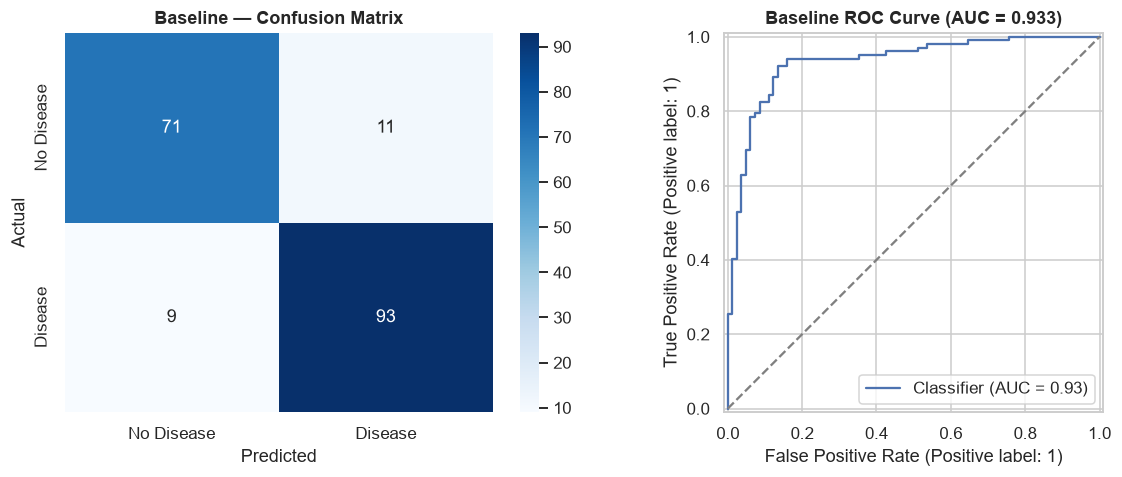

In [16]:
# 📊 Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"], ax=axes[0])
axes[0].set_title("Baseline — Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[1].set_title(f"Baseline ROC Curve (AUC = {baseline_roc_auc:.3f})")
plt.tight_layout()
plt.show()


<div style="background-color:#eef6fb; padding:15px; border-radius:8px; border-left:4px solid #16a34a;">
<b>Observation</b><br><br>
The confusion matrix shows the baseline correctly separates most patients, with a <b>small number of false negatives</b> — the more clinically costly error, since a missed heart-disease case is worse than a false alarm. The ROC curve sits well above the diagonal, confirming the model is doing meaningfully better than random guessing. This gives us a solid, honest number to beat with the neural network.
</div>


### Step 5 — 📌 Baseline Score of Record

> ## 🎯 BASELINE TO BEAT
> **Model:** Logistic Regression
> **Accuracy:** 0.8913 * 
> **ROC-AUC:** *0.9312*
>
> **Every model trained for the rest of Phase 3 — including this week's neural network — must beat this score to justify the added complexity.**



## 8. Key Takeaways & Next Steps

- ✅ Sprint 1 planned: goal confirmed, backlog committed to, Definition of Done set.
- ✅ A neuron = **dot product + bias + activation** — nothing more.
- ✅ Layers (input → hidden → output) stack neurons; "deep" = multiple hidden layers.
- ✅ Weights & biases are the *learned* parameters — random today, tuned by Day 3–4.
- ✅ Baseline Logistic Regression trained and recorded — **this is the number to beat.**

### 📺 Week 6 Resources
1. [Deep Learning 1](https://www.youtube.com/watch?v=p93xuOXP1jI&list=PL6-3IRz2XF5X-lzMZdmkvGAx1a3kIm7_I&index=1)
2. [Deep Learning 2](https://www.youtube.com/watch?v=weyvz30VTHI&list=PL6-3IRz2XF5X-lzMZdmkvGAx1a3kIm7_I&index=2)

### ➡️ Day 2 Preview
Activation functions in depth, forward propagation, and choosing the right **loss function** for the cardiac classification task (binary cross-entropy).
